## DP1 CDFS astrometry diagnostics

This notebook validates the astrometric behaviour of the LSST–VISTA Fusion Pipeline products in the CDFS/ECDFS region. The DP1 catalogue provides the pipeline source positions, and Gaia DR3 is used as the external astrometric reference catalogue.

The main comparison is between the DP1/VIRCAM `K`-band catalogue coordinates and Gaia DR3 positions propagated to different reference epochs. This is important because Gaia DR3 includes proper motions, and the apparent position of a star changes with epoch. The notebook therefore propagates Gaia positions to several epochs before matching, rather than assuming that all catalogues are defined at the same epoch.

The notebook performs the following checks:

1. Load the DP1 and VIDEO public catalogues.
2. Define the astrometric coordinate columns used for the comparison.
3. Inspect the DP1 sky coverage.
4. Query or load a Gaia DR3 reference sample over the CDFS/ECDFS footprint.
5. Propagate Gaia positions to J2000, J2010, J2016, and J2026.
6. Compare DP1 positions with Gaia at each propagated epoch.
7. Compare VIDEO positions with Gaia at each propagated epoch as a consistency check.
8. Adopt Gaia@J2016 for the main DP1 comparison and Gaia@J2010 for the approximate VIDEO comparison.
9. Produce residual-cloud, separation, and final publication-style astrometry plots.

Residuals are reported as `ΔRA cos(Dec)` and `ΔDec` in arcseconds. The robust scatter is measured using the NMAD. The matching uses nearest-neighbour associations with a separation limit and a simple isolation condition based on the second-nearest Gaia source.

### 1. Imports and paths

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

import astropy.units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.time import Time

from astroquery.gaia import Gaia

from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------

DATA_DIR = Path("../data")
DP1_PATH = DATA_DIR / "full_reduced_cat_DP1_20260408.fits"
VIDEO_PATH = DATA_DIR / "VISTA-VIDEO-CDFS-DR5.fits"

OUTDIR = Path("data/plots_astrometry")
OUTDIR.mkdir(parents=True, exist_ok=True)

GAIA_CACHE = DATA_DIR / "gaia_dr3_cdfs_astrometry.fits"

print("DP1 path   :", DP1_PATH)
print("VIDEO path :", VIDEO_PATH)
print("Output dir :", OUTDIR)
print("Gaia cache :", GAIA_CACHE)

Status messages could not be retrieved
DP1 path   : ../data/full_reduced_cat_DP1_20260408.fits
VIDEO path : ../data/VISTA-VIDEO-CDFS-DR5.fits
Output dir : data/plots_astrometry
Gaia cache : ../data/gaia_dr3_cdfs_astrometry.fits


### 2. Load DP1 and VIDEO catalogues

In [2]:
dp1 = Table.read(DP1_PATH)
vid = Table.read(VIDEO_PATH)

print("N(DP1)   =", len(dp1))
print("N(VIDEO) =", len(vid))
print("N DP1 columns   =", len(dp1.colnames))
print("N VIDEO columns =", len(vid.colnames))

N(DP1)   = 1380173
N(VIDEO) = 1138485
N DP1 columns   = 87
N VIDEO columns = 389


### 3. Define astrometric coordinate columns

The DP1 coordinates are stored in radians in the reduced catalogue. The VIDEO public catalogue coordinates are in degrees. I explicitly attach units when creating the `SkyCoord` objects to avoid any ambiguity.

In [3]:
# DP1 catalogue coordinates used for the astrometric validation.
# These are VIRCAM-K forced-photometry catalogue positions.
DP1_RA  = "VIRCAM_K_m_coord_ra"
DP1_DEC = "VIRCAM_K_m_coord_dec"

# VIDEO public catalogue coordinates.
VID_RA  = "RA2000"
VID_DEC = "DEC2000"

ra_dp1_rad = np.asarray(dp1[DP1_RA], dtype=float)
dec_dp1_rad = np.asarray(dp1[DP1_DEC], dtype=float)

ra_vid_deg = np.asarray(vid[VID_RA], dtype=float)
dec_vid_deg = np.asarray(vid[VID_DEC], dtype=float)

m_dp1_coord = np.isfinite(ra_dp1_rad) & np.isfinite(dec_dp1_rad)
m_vid_coord = np.isfinite(ra_vid_deg) & np.isfinite(dec_vid_deg)

dp1c = dp1[m_dp1_coord]
vidc = vid[m_vid_coord]

c_dp1 = SkyCoord(
    ra=ra_dp1_rad[m_dp1_coord] * u.rad,
    dec=dec_dp1_rad[m_dp1_coord] * u.rad,
    frame="icrs",
)

c_vid = SkyCoord(
    ra=ra_vid_deg[m_vid_coord] * u.deg,
    dec=dec_vid_deg[m_vid_coord] * u.deg,
    frame="icrs",
)

print("Finite DP1 coordinates  :", len(dp1c), "/", len(dp1))
print("Finite VIDEO coordinates:", len(vidc), "/", len(vid))
print("DP1 coordinate columns  :", DP1_RA, DP1_DEC)
print("VIDEO coordinate columns:", VID_RA, VID_DEC)

Finite DP1 coordinates  : 1380173 / 1380173
Finite VIDEO coordinates: 1138485 / 1138485
DP1 coordinate columns  : VIRCAM_K_m_coord_ra VIRCAM_K_m_coord_dec
VIDEO coordinate columns: RA2000 DEC2000


### 4. Sky coverage of the DP1 catalogue

This plot is only a quick footprint inspection. It uses the same DP1 coordinates as the astrometric comparison and colours the points by the VIRCAM `K` aperture magnitude.

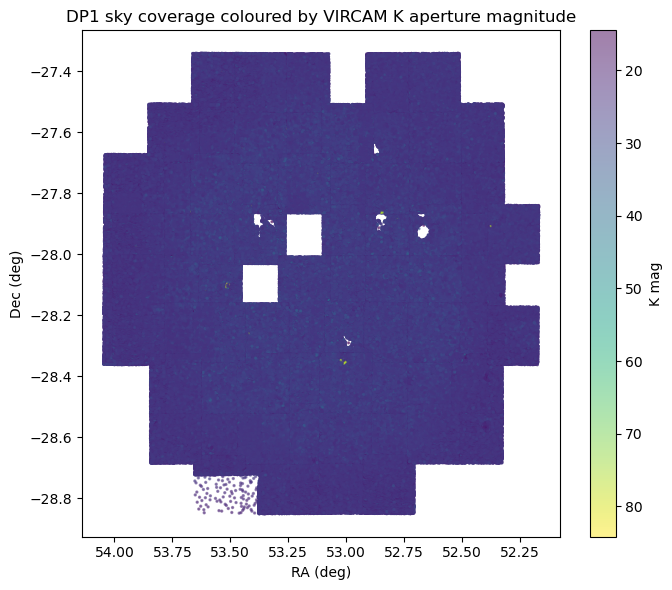

In [4]:
ra_deg = c_dp1.ra.deg
dec_deg = c_dp1.dec.deg
kmag = np.asarray(dp1c["VIRCAM_K_m_base_CircularApertureFlux_6_0_mag"], dtype=float)

ok = np.isfinite(ra_deg) & np.isfinite(dec_deg) & np.isfinite(kmag)

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    ra_deg[ok],
    dec_deg[ok],
    c=kmag[ok],
    s=2,
    alpha=0.5,
    rasterized=True,
)
plt.gca().invert_xaxis()
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.title("DP1 sky coverage coloured by VIRCAM K aperture magnitude")
cb = plt.colorbar(sc)
cb.set_label("K mag")
cb.ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTDIR / "dp1_sky_coverage_kmag.png", dpi=250)
plt.show()

### 5. Query or load Gaia DR3 reference stars

The Gaia query is restricted to the CDFS/ECDFS region and uses a simple quality selection. The result is cached locally, so the notebook does not need to query Gaia every time it is run.

In [5]:
# CDFS/ECDFS bounding box in degrees.
ra_min, ra_max = 52.1, 54.1
dec_min, dec_max = -28.9, -27.3

GMAX = 24.0

if GAIA_CACHE.exists():
    gaia = Table.read(GAIA_CACHE)
    print("Loaded Gaia cache:", GAIA_CACHE)
else:
    query = f'''
    SELECT source_id, ra, dec, pmra, pmdec, ref_epoch, phot_g_mean_mag, ruwe
    FROM gaiadr3.gaia_source
    WHERE ra BETWEEN {ra_min} AND {ra_max}
    AND dec BETWEEN {dec_min} AND {dec_max}
    AND phot_g_mean_mag < {GMAX}
    AND pmra IS NOT NULL AND pmdec IS NOT NULL
    AND ruwe < 1.8
    '''

    job = Gaia.launch_job_async(query)
    gaia = job.get_results()
    gaia.write(GAIA_CACHE, overwrite=True)
    print("Queried Gaia and wrote cache:", GAIA_CACHE)

print("N(Gaia) =", len(gaia))
print("Gaia columns:", gaia.colnames)

Loaded Gaia cache: ../data/gaia_dr3_cdfs_astrometry.fits
N(Gaia) = 7256
Gaia columns: ['source_id', 'ra', 'dec', 'pmra', 'pmdec', 'ref_epoch', 'phot_g_mean_mag', 'ruwe']


### 6. Build Gaia coordinates and propagate them to several epochs

Gaia DR3 positions are propagated using the Gaia proper motions. I test several epochs to show how the choice of reference epoch affects the residuals.

In [6]:
def quantity_column(tab, col, unit):
    values = np.asarray(tab[col], dtype=float)
    current_unit = getattr(tab[col], "unit", None)
    if current_unit is None:
        return values * unit
    return tab[col].quantity.to(unit)

t_ref = Time(np.asarray(gaia["ref_epoch"], dtype=float), format="jyear")

c_g_ref = SkyCoord(
    ra=quantity_column(gaia, "ra", u.deg),
    dec=quantity_column(gaia, "dec", u.deg),
    pm_ra_cosdec=quantity_column(gaia, "pmra", u.mas / u.yr),
    pm_dec=quantity_column(gaia, "pmdec", u.mas / u.yr),
    obstime=t_ref,
    frame="icrs",
)

EPOCHS = {
    "J2000": c_g_ref.apply_space_motion(new_obstime=Time("J2000.0")),
    "J2010": c_g_ref.apply_space_motion(new_obstime=Time("J2010.0")),
    "J2016": c_g_ref.apply_space_motion(new_obstime=Time("J2016.0")),
    "J2026": c_g_ref.apply_space_motion(new_obstime=Time("J2026.0")),
}

for name in EPOCHS:
    print("Prepared Gaia positions at", name)

Prepared Gaia positions at J2000
Prepared Gaia positions at J2010
Prepared Gaia positions at J2016
Prepared Gaia positions at J2026


/mnt/scratch/lsst-ir-fusion/install/source/v29.1.1/conda/miniconda3-py38_4.9.2/envs/lsst-scipipe-10.0.0/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "pmsafe" yielded 7256 of "distance overridden (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


### 7. Matching, residual, and robust-statistics helpers

The `match_isolated_nearest` function keeps nearest-neighbour matches within a chosen radius and removes cases where the second-nearest reference source is too close. This is not a strict mutual one-to-one match, but it is a useful isolation cut for astrometric validation.

In [7]:
def nmad(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.nanmedian(x)
    return 1.4826 * np.nanmedian(np.abs(x - med))


def match_isolated_nearest(c_src, c_ref, radius=0.5*u.arcsec, isolation_ratio=1.5):
    # Nearest-neighbour match with a simple isolation requirement.
    idx1, sep1, _ = c_src.match_to_catalog_sky(c_ref)
    idx2, sep2, _ = c_src.match_to_catalog_sky(c_ref, nthneighbor=2)

    keep = (
        (sep1 < radius)
        & np.isfinite(sep1.arcsec)
        & np.isfinite(sep2.arcsec)
        & (sep2 > isolation_ratio * sep1)
    )

    return idx1, sep1, keep


def residuals_arcsec(c_src, c_ref, idx, keep):
    # Return dRA*cosDec, dDec, and separation in arcsec.
    dra = (c_src.ra[keep] - c_ref[idx[keep]].ra).to(u.arcsec).value
    ddec = (c_src.dec[keep] - c_ref[idx[keep]].dec).to(u.arcsec).value

    dra_cos = dra * np.cos(c_src.dec[keep].to(u.rad).value)
    sep = c_src[keep].separation(c_ref[idx[keep]]).to(u.arcsec).value

    return dra_cos, ddec, sep


def print_stats(tag, dra_cos, ddec, sep):
    print(tag)
    print("  N:", int(np.isfinite(sep).sum()))
    print("  med dRA*cosDec [arcsec]:", np.nanmedian(dra_cos), " NMAD:", nmad(dra_cos))
    print("  med dDec       [arcsec]:", np.nanmedian(ddec),    " NMAD:", nmad(ddec))
    print("  med sep        [arcsec]:", np.nanmedian(sep))
    print("  p95 sep        [arcsec]:", np.nanpercentile(sep, 95))
    print()

### 8. DP1 versus Gaia at different propagated epochs

This cell shows the epoch dependence of the DP1–Gaia astrometric residuals. The final DP1 comparison adopts Gaia propagated to J2016, which is close to the Gaia DR3 reference epoch and gives the most appropriate comparison for this diagnostic.

In [8]:
dp1_results = {}

for name, c_g in EPOCHS.items():
    idx, sep, keep = match_isolated_nearest(
        c_dp1,
        c_g,
        radius=0.5*u.arcsec,
        isolation_ratio=1.5,
    )

    dra_cos, ddec, sep_arc = residuals_arcsec(c_dp1, c_g, idx, keep)

    dp1_results[name] = {
        "idx": idx,
        "sep_raw": sep,
        "keep": keep,
        "dra_cos": dra_cos,
        "ddec": ddec,
        "sep": sep_arc,
    }

    print_stats(f"DP1 - Gaia({name})", dra_cos, ddec, sep_arc)

DP1 - Gaia(J2000)
  N: 11385
  med dRA*cosDec [arcsec]: 0.08741144631204723  NMAD: 0.13009206568614784
  med dDec       [arcsec]: -0.036933409981543264  NMAD: 0.12825338284469467
  med sep        [arcsec]: 0.17451279403396472
  p95 sep        [arcsec]: 0.4307177387506849

DP1 - Gaia(J2010)
  N: 12515
  med dRA*cosDec [arcsec]: 0.04726251146886665  NMAD: 0.09928897454977281
  med dDec       [arcsec]: -0.01901462444777735  NMAD: 0.08995286306488708
  med sep        [arcsec]: 0.1187430318570241
  p95 sep        [arcsec]: 0.37819805920714544

DP1 - Gaia(J2016)
  N: 12968
  med dRA*cosDec [arcsec]: 0.019204321247302418  NMAD: 0.08568653823925555
  med dDec       [arcsec]: -0.008402229133253059  NMAD: 0.07872007346251507
  med sep        [arcsec]: 0.09749975897652262
  p95 sep        [arcsec]: 0.3091973494907945

DP1 - Gaia(J2026)
  N: 12939
  med dRA*cosDec [arcsec]: -0.0355172918436642  NMAD: 0.09117135402363964
  med dDec       [arcsec]: 0.010946699853775499  NMAD: 0.09121911698203916
  m

### 9. VIDEO versus Gaia at different propagated epochs

This is a consistency check using the VIDEO public catalogue. For the final VIDEO comparison I adopt Gaia propagated to J2010 as an approximate effective VISTA epoch. The VIDEO epoch is approximate and is not used as the main DP1 validation result.

In [9]:
vid_results = {}

for name, c_g in EPOCHS.items():
    idx, sep, keep = match_isolated_nearest(
        c_vid,
        c_g,
        radius=0.5*u.arcsec,
        isolation_ratio=1.5,
    )

    dra_cos, ddec, sep_arc = residuals_arcsec(c_vid, c_g, idx, keep)

    vid_results[name] = {
        "idx": idx,
        "sep_raw": sep,
        "keep": keep,
        "dra_cos": dra_cos,
        "ddec": ddec,
        "sep": sep_arc,
    }

    print_stats(f"VIDEO - Gaia({name})", dra_cos, ddec, sep_arc)

VIDEO - Gaia(J2000)
  N: 6574
  med dRA*cosDec [arcsec]: -0.028995639741032357  NMAD: 0.1199695454794885
  med dDec       [arcsec]: 0.024742740189509504  NMAD: 0.11892033309927186
  med sep        [arcsec]: 0.14728954900192479
  p95 sep        [arcsec]: 0.36354527987083657

VIDEO - Gaia(J2010)
  N: 6891
  med dRA*cosDec [arcsec]: -0.08140639528703546  NMAD: 0.08422459947647883
  med dDec       [arcsec]: 0.04557837499419293  NMAD: 0.07872616128645858
  med sep        [arcsec]: 0.1296065312887344
  p95 sep        [arcsec]: 0.2464132256482689

VIDEO - Gaia(J2016)
  N: 6903
  med dRA*cosDec [arcsec]: -0.12079423638414437  NMAD: 0.07616477829919657
  med dDec       [arcsec]: 0.0638570743035416  NMAD: 0.07303257847831815
  med sep        [arcsec]: 0.15784379169359702
  p95 sep        [arcsec]: 0.26328285255703865

VIDEO - Gaia(J2026)
  N: 6439
  med dRA*cosDec [arcsec]: -0.1683342820442319  NMAD: 0.1085155403086978
  med dDec       [arcsec]: 0.08196900414105812  NMAD: 0.1087549510666372
  me

### 10. Adopt the main comparison epochs

For the rest of the notebook, the main DP1 astrometric comparison uses Gaia@J2016. The VIDEO comparison uses Gaia@J2010 only as an approximate check of the public VIDEO positions.

In [10]:
DP1_EPOCH_MAIN = "J2016"
VIDEO_EPOCH_MAIN = "J2010"

dra_dp1 = dp1_results[DP1_EPOCH_MAIN]["dra_cos"]
ddec_dp1 = dp1_results[DP1_EPOCH_MAIN]["ddec"]
sep_dp1 = dp1_results[DP1_EPOCH_MAIN]["sep"]

dra_vid = vid_results[VIDEO_EPOCH_MAIN]["dra_cos"]
ddec_vid = vid_results[VIDEO_EPOCH_MAIN]["ddec"]
sep_vid = vid_results[VIDEO_EPOCH_MAIN]["sep"]

print_stats(f"Adopted DP1 - Gaia({DP1_EPOCH_MAIN})", dra_dp1, ddec_dp1, sep_dp1)
print_stats(f"Adopted VIDEO - Gaia({VIDEO_EPOCH_MAIN})", dra_vid, ddec_vid, sep_vid)

Adopted DP1 - Gaia(J2016)
  N: 12968
  med dRA*cosDec [arcsec]: 0.019204321247302418  NMAD: 0.08568653823925555
  med dDec       [arcsec]: -0.008402229133253059  NMAD: 0.07872007346251507
  med sep        [arcsec]: 0.09749975897652262
  p95 sep        [arcsec]: 0.3091973494907945

Adopted VIDEO - Gaia(J2010)
  N: 6891
  med dRA*cosDec [arcsec]: -0.08140639528703546  NMAD: 0.08422459947647883
  med dDec       [arcsec]: 0.04557837499419293  NMAD: 0.07872616128645858
  med sep        [arcsec]: 0.1296065312887344
  p95 sep        [arcsec]: 0.2464132256482689



### 11. Residual-cloud comparison for the adopted epochs

This plot compares the residual clouds for DP1 and VIDEO using the adopted Gaia propagation epochs.

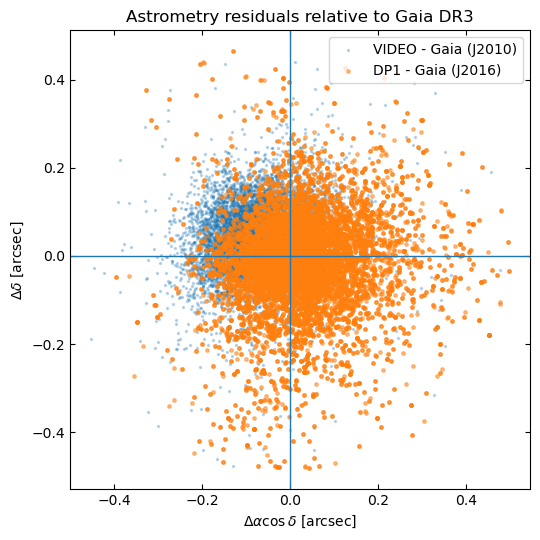

In [11]:
plt.figure(figsize=(5.5, 5.5))

plt.scatter(
    dra_vid,
    ddec_vid,
    s=2,
    alpha=0.25,
    label=f"VIDEO - Gaia ({VIDEO_EPOCH_MAIN})",
    rasterized=True,
)

plt.scatter(
    dra_dp1,
    ddec_dp1,
    s=6,
    alpha=0.50,
    label=f"DP1 - Gaia ({DP1_EPOCH_MAIN})",
    rasterized=True,
)

plt.axhline(0, lw=1)
plt.axvline(0, lw=1)
plt.xlabel("$\\Delta\\alpha\\cos\\delta$ [arcsec]")
plt.ylabel("$\\Delta\\delta$ [arcsec]")
plt.title("Astrometry residuals relative to Gaia DR3")
plt.legend(loc="upper right")
plt.tick_params(direction="in", top=True, right=True)
plt.tight_layout()
plt.savefig(OUTDIR / "residual_clouds_gaia_adopted_epochs.png", dpi=300)
plt.show()

### 12. DP1–Gaia residuals coloured by Gaia G magnitude

This diagnostic checks whether the astrometric residuals show a strong dependence on Gaia brightness.

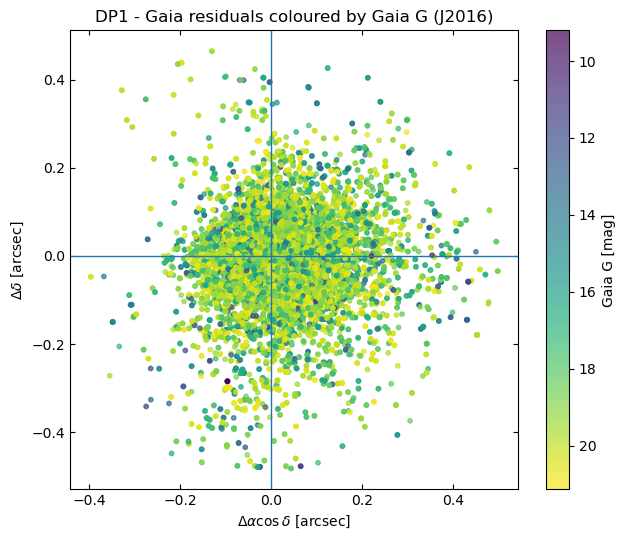

In [12]:
idx_dp1 = dp1_results[DP1_EPOCH_MAIN]["idx"]
keep_dp1 = dp1_results[DP1_EPOCH_MAIN]["keep"]

gmag = np.asarray(gaia["phot_g_mean_mag"][idx_dp1[keep_dp1]], dtype=float)

plt.figure(figsize=(6.5, 5.5))
sc = plt.scatter(
    dra_dp1,
    ddec_dp1,
    c=gmag,
    s=10,
    alpha=0.7,
    rasterized=True,
)

plt.axhline(0, lw=1)
plt.axvline(0, lw=1)
plt.xlabel("$\\Delta\\alpha\\cos\\delta$ [arcsec]")
plt.ylabel("$\\Delta\\delta$ [arcsec]")
plt.title(f"DP1 - Gaia residuals coloured by Gaia G ({DP1_EPOCH_MAIN})")

cb = plt.colorbar(sc)
cb.set_label("Gaia G [mag]")
cb.ax.invert_yaxis()

plt.tick_params(direction="in", top=True, right=True)
plt.tight_layout()
plt.savefig(OUTDIR / f"dp1_gaia_residuals_coloured_G_{DP1_EPOCH_MAIN}.png", dpi=300)
plt.show()

### 13. Compact DP1–Gaia astrometry summary plot

This figure shows the DP1–Gaia residual cloud and the distribution of match separations for the adopted DP1 epoch.

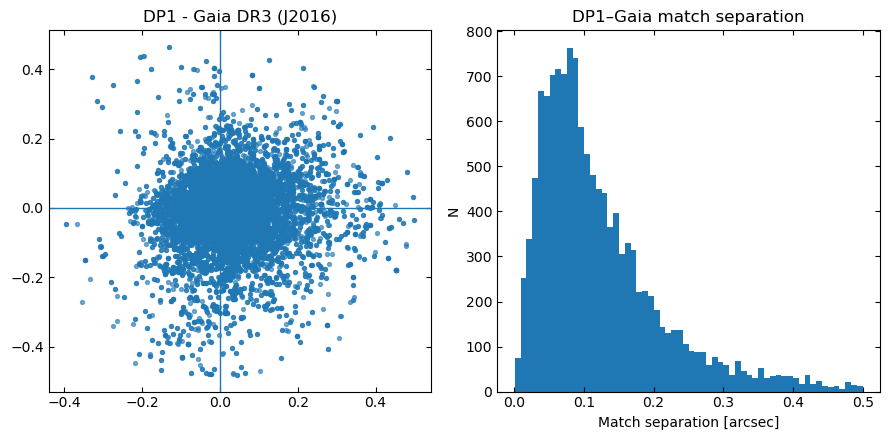

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

for ax in axes:
    ax.tick_params(direction="in", which="both", top=True, right=True)

# Residual cloud
ax = axes[0]
ax.scatter(dra_dp1, ddec_dp1, s=8, alpha=0.6, rasterized=True)
ax.axhline(0, lw=1)
ax.axvline(0, lw=1)
plt.xlabel("$\\Delta\\alpha\\cos\\delta$ [arcsec]")
plt.ylabel("$\\Delta\\delta$ [arcsec]")
ax.set_title(f"DP1 - Gaia DR3 ({DP1_EPOCH_MAIN})")

# Separation histogram
ax = axes[1]
ax.hist(sep_dp1, bins=60)
ax.set_xlabel("Match separation [arcsec]")
ax.set_ylabel("N")
ax.set_title("DP1–Gaia match separation")

plt.tight_layout()
plt.savefig(OUTDIR / "dp1_gaia_astrometry_summary.pdf", dpi=300)
plt.show()

### 14. Publication-style astrometry plot helper

This helper creates a combined residual-density plot with one-dimensional marginal histograms. It also optionally highlights a high-S/N subset using the DP1 magnitude-error based S/N estimate.

In [14]:
def _normal_pdf(x, mu, sig):
    if not np.isfinite(sig) or sig <= 0:
        return np.zeros_like(x, dtype=float)
    return np.exp(-0.5 * ((x - mu) / sig) ** 2) / (sig * np.sqrt(2 * np.pi))


def astrometry_plot(
    dra_arcsec,
    ddec_arcsec,
    snr=None,
    snr_cut=20.0,
    lim=0.5,
    gridsize=85,
    bins_1d=100,
    match_radius=0.5,
    title="DP1 - Gaia astrometry",
    output_path=None,
):
    dra = np.asarray(dra_arcsec, float)
    ddec = np.asarray(ddec_arcsec, float)

    ok = np.isfinite(dra) & np.isfinite(ddec)

    if snr is not None:
        snr = np.asarray(snr, float)
        ok &= np.isfinite(snr)

    dra = dra[ok]
    ddec = ddec[ok]

    if snr is not None:
        snr = snr[ok]

    if dra.size == 0:
        raise RuntimeError("No finite residuals to plot.")

    sep = np.hypot(dra, ddec)

    if snr is not None:
        hi = snr > snr_cut
    else:
        hi = np.zeros_like(dra, dtype=bool)

    dra_hi = dra[hi]
    ddec_hi = ddec[hi]

    mdra = np.nanmedian(dra)
    mddec = np.nanmedian(ddec)
    sdra = nmad(dra)
    sddec = nmad(ddec)
    msep = np.nanmedian(sep)
    p95 = np.nanpercentile(sep, 95)

    mdra_hi = np.nanmedian(dra_hi) if dra_hi.size else np.nan
    mddec_hi = np.nanmedian(ddec_hi) if ddec_hi.size else np.nan
    sdra_hi = nmad(dra_hi)
    sddec_hi = nmad(ddec_hi)

    fig = plt.figure(figsize=(8.2, 7.2))
    ax_main = fig.add_subplot(111)

    divider = make_axes_locatable(ax_main)
    ax_top = divider.append_axes("top", size=1.1, pad=0.0, sharex=ax_main)
    ax_right = divider.append_axes("right", size=1.1, pad=0.0, sharey=ax_main)
    cax = divider.append_axes("right", size="4.5%", pad=0.08)

    hb = ax_main.hexbin(
        dra,
        ddec,
        gridsize=gridsize,
        extent=(-lim, lim, -lim, lim),
        mincnt=1,
        bins="log",
        cmap="Blues",
    )

    ax_main.axvline(0, lw=1, ls=":", color="grey")
    ax_main.axhline(0, lw=1, ls=":", color="grey")

    circ = Circle((0, 0), match_radius, fill=False, ls=":", lw=1.0, alpha=0.8)
    ax_main.add_patch(circ)

    ax_main.set_xlim(-lim, lim)
    ax_main.set_ylim(-lim, lim)
    ax_main.set_aspect("equal", adjustable="box")
    ax_main.set_xlabel("Residual RA (arcsec)")
    ax_main.set_ylabel("Residual Dec (arcsec)")
    ax_main.tick_params(direction="in", top=True, right=True)

    edges = np.linspace(-lim, lim, bins_1d + 1)
    centres = 0.5 * (edges[:-1] + edges[1:])
    bin_width = edges[1] - edges[0]

    ax_top.hist(dra, bins=edges, histtype="step", lw=1.2, label="All")

    if dra_hi.size:
        ax_top.hist(
            dra_hi,
            bins=edges,
            histtype="step",
            lw=1.2,
            label=f"S/N > {snr_cut:g}",
        )

    if dra_hi.size > 10 and np.isfinite(sdra_hi) and sdra_hi > 0:
        y = dra_hi.size * bin_width * _normal_pdf(centres, mdra_hi, sdra_hi)
        ax_top.plot(
            centres,
            y,
            lw=1.0,
            color="black",
            label=rf"$\mathcal{{N}}(\mu,\sigma={sdra_hi:.3f})$",
        )

    ax_top.set_ylabel("Count")
    ax_top.tick_params(direction="in", top=True, right=True, labelbottom=False)
    ax_top.legend(loc="upper left", frameon=False, fontsize=10)

    ax_right.hist(
        ddec,
        bins=edges,
        histtype="step",
        lw=1.2,
        orientation="horizontal",
    )

    if ddec_hi.size:
        ax_right.hist(
            ddec_hi,
            bins=edges,
            histtype="step",
            lw=1.2,
            orientation="horizontal",
        )

    if ddec_hi.size > 10 and np.isfinite(sddec_hi) and sddec_hi > 0:
        x = ddec_hi.size * bin_width * _normal_pdf(centres, mddec_hi, sddec_hi)
        ax_right.plot(x, centres, lw=1.0, color="black")

    ax_right.set_xlabel("Count")
    ax_right.tick_params(direction="in", top=True, right=True, labelleft=False)

    cb = fig.colorbar(hb, cax=cax)
    cb.ax.tick_params(which="both", direction="in", right=True, left=True)
    cb.set_label("")

    cb.ax.text(
        0.5,
        0.5,
        "Points per bin",
        transform=cb.ax.transAxes,
        rotation=90,
        ha="center",
        va="center",
        color="white",
        fontsize=11,
        path_effects=[pe.withStroke(linewidth=2, foreground="black")],
    )

    txt = (
        f"{title}  [arcsec]\n"
        f"N = {dra.size}\n"
        f"dRA*cosDec: median={mdra:+.4f}  NMAD={sdra:.4f}\n"
        f"dDec     : median={mddec:+.4f}  NMAD={sddec:.4f}\n"
        f"sep      : median={msep:.4f}   95%={p95:.4f}"
    )

    ax_top.text(
        0.01,
        1.20,
        txt,
        transform=ax_top.transAxes,
        ha="left",
        va="bottom",
    )

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

### 15. Final DP1–Gaia astrometry figure

The S/N estimate is derived from the DP1 K-band magnitude uncertainty using `S/N ≈ 1.0857 / magErr`. This is only used to highlight a high-S/N subset in the marginal histograms.

len(dra_dp1)  = 12968
len(ddec_dp1) = 12968
len(dp1_matched) = 12968
len(snr_use) = 12968


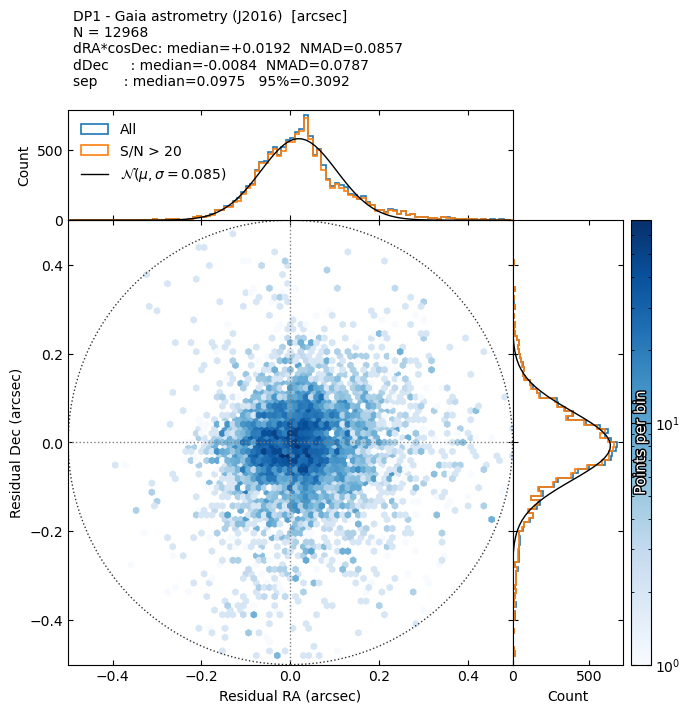

In [15]:
dp1_matched = dp1c[dp1_results[DP1_EPOCH_MAIN]["keep"]]

snr_use = np.asarray(
    1.0857 / dp1_matched["VIRCAM_K_m_base_CircularApertureFlux_6_0_magErr"],
    dtype=float,
)

print("len(dra_dp1)  =", len(dra_dp1))
print("len(ddec_dp1) =", len(ddec_dp1))
print("len(dp1_matched) =", len(dp1_matched))
print("len(snr_use) =", len(snr_use))

astrometry_plot(
    dra_dp1,
    ddec_dp1,
    snr=snr_use,
    snr_cut=20,
    lim=0.5,
    gridsize=85,
    bins_1d=100,
    match_radius=0.5,
    title=f"DP1 - Gaia astrometry ({DP1_EPOCH_MAIN})",
    output_path=OUTDIR / f"dp1_gaia_astrometry_final_{DP1_EPOCH_MAIN}.png",
)